# derived_8.4-eval-1.4 — LOSO Spatial Generalization: Gating K-Sweep & Clustering Feature Sets

This experiment is `derived_8.4-eval-1.3` (2 baselines + 5 MoE routing strategies × 9 per-regime delta-grid points + the 9-point `Clustering_Backbone54_k2` grid = 56 configurations, all sharing the same 54-feature backbone / V0-50 baseline / candidate pool / XGBoost hyperparameters) **plus 12 new clustering configurations** from `derived_8.4-gating-analysis-1.0`: the K-sweep (K = 2, 3, 4) of the 5 clustering routers (54-backbone, 58 static attributes, 16 weather drivers, 3 dynamic features, 50 V0 features), minus the three k2 combos already evaluated in eval-1.3. Each new configuration is a **single config** (no delta grid) whose per-regime experts use **only the 54 shared-backbone features** — no per-regime feature additions were conducted for these regimes, so the backbone-only configuration is the only defensible one. Routing follows the gating-analysis recipe (mean-impute → StandardScaler → KMeans(random_state=42, n_init=10)) and is refitted per LOSO fold on the fold trainval only.

Execution follows the `derived_8.4-eval-2.0` **parallel worker format**: the driver spawns 8 `run_loso_worker.py` subprocesses, each training one (config, station) fold on the H100 GPU concurrently (scheduled via `sbatch run_slurm.sh`, `--time=02:00:00 --partition=gpu_debug --gres=gpu:h100:1 --cpus-per-task=6 --mem=16000 --nodes 1`). For each of the 68 configurations and each held-out station $s$: the router is refitted and experts are trained on the trainval rows of the **remaining 6 stations** (train 2017–2020 + val 2021–2022), then evaluated on all test rows of station $s$ (2023–2025). The 56 existing configurations' recorded results are merged as **references from eval-1.3** (identical protocol, seed 42, xgboost 3.2.0 — no retraining); only the 12 new configurations are computed here (84 LOSO folds + 12 full-baseline configs).


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import json
from IPython.display import Image, display

# Robust resolution of the experiment dir whether executed from notebooks/ or in-place.
candidates = [Path.cwd() / "experiment/derived_8.4-eval-1.4", Path.cwd()]
EXP_DIR = next((p for p in candidates if (p / "loso_config_summary.csv").exists()), Path.cwd())

df_summary = pd.read_csv(EXP_DIR / "loso_config_summary.csv")
df_station = pd.read_csv(EXP_DIR / "loso_station_summary.csv")
df_pcs = pd.read_csv(EXP_DIR / "loso_per_config_station.csv")
df_regime = pd.read_csv(EXP_DIR / "loso_per_regime_metrics.csv")
df_year = pd.read_csv(EXP_DIR / "loso_per_year_metrics.csv")

print(f"Loaded {len(df_summary)} configurations, {len(df_station)} stations, "
      f"{len(df_pcs)} config×station folds, {len(df_regime)} regime rows, {len(df_year)} year rows.")


Loaded 68 configurations, 7 stations, 476 config×station folds, 1043 regime rows, 1428 year rows.


## LOSO Configuration Leaderboard

Mean $R^2$ across the 7 held-out stations (each model trained on the other 6 stations, tested on the held-out one). `loso_mean_r2` is the average of per-station $R^2$; `loso_pooled_r2` is the sample-count-weighted $R^2$ over the concatenated 6,620 held-out test samples (directly comparable to eval-1.1's pooled test $R^2$); `loso_min/max_r2` show the spread across stations; `loso_mean_rmse` / `loso_mean_mae` / `loso_mean_bias` are the per-station-mean RMSE / MAE / bias. `temporal_test_r2` is the configuration's *temporal* test $R^2$, and `temporal_test_rmse` / `temporal_test_bias` / `temporal_test_mae` its pooled RMSE / bias / MAE on the same test set — from `derived_8.4-eval-1.1` for the 47 pinned configurations (the full-training baseline replicates it to 0.000000), and from the full-training baseline (`full_config_summary.csv`) for the other 21: the 9 `Clustering_Backbone54_k2` grid points have no eval-1.1 row and their rows are eval-1.3 references recorded under the identical protocol; the 12 new gating configurations were computed here. `loso_minus_test_r2` is the spatial-generalization gap (mean-of-stations version).

**Provenance.** The 56 eval-1.1/eval-1.3 configurations were already evaluated under the identical LOSO protocol in `derived_8.4-eval-1.3` (same seed 42, same xgboost 3.2.0 environment — its full baseline replicated eval-1.1 to 0.000000), so they are merged as references (`is_reference = True`) rather than recomputed; only the 12 new gating K-sweep configurations were computed in this experiment.

In [2]:
leaderboard_cols = [
    "config_label", "strategy_name", "loso_mean_r2", "loso_pooled_r2", "loso_std_r2",
    "loso_min_r2", "loso_max_r2", "loso_mean_rmse", "loso_mean_mae", "loso_mean_bias",
    "temporal_test_r2", "temporal_test_rmse", "temporal_test_bias", "temporal_test_mae",
    "loso_minus_test_r2", "is_winner",
]
print(f"### LOSO Configuration Leaderboard (mean R² over 7 held-out stations; "
      f"{int(df_summary['is_reference'].sum())} referenced from eval-1.3, "
      f"{int((~df_summary['is_reference']).sum())} computed in eval-1.4)")
print(df_summary[leaderboard_cols].to_markdown(index=False))

### LOSO Configuration Leaderboard (mean R² over 7 held-out stations; 56 referenced from eval-1.3, 12 computed in eval-1.4)


| config_label                           | strategy_name            |   loso_mean_r2 |   loso_pooled_r2 |   loso_std_r2 |   loso_min_r2 |   loso_max_r2 |   loso_mean_rmse |   loso_mean_mae |   loso_mean_bias |   temporal_test_r2 |   temporal_test_rmse |   temporal_test_bias |   temporal_test_mae |   loso_minus_test_r2 | is_winner   |
|:---------------------------------------|:-------------------------|---------------:|-----------------:|--------------:|--------------:|--------------:|-----------------:|----------------:|-----------------:|-------------------:|---------------------:|---------------------:|--------------------:|---------------------:|:------------|
| Clustering_V0_Full_k2  c0=0, c1=10     | Clustering_V0_Full_k2    |       0.641545 |         0.688536 |      0.123588 |      0.427317 |      0.779948 |        0.0557425 |       0.0444562 |       0.0156391  |           0.81496  |            0.0438196 |           0.00648567 |           0.0337195 |            -0.173415 | True  

## Station Difficulty (Byproduct)

Aggregating LOSO $R^2$ over all 56 configurations per held-out station reveals which stations are intrinsically harder to generalize to (fewer stations share their climate/soil regime). `n_negative_r2` counts how many of the 56 configurations produced a negative $R^2$ when that station was held out.


In [3]:
station_cols = ["station", "n_configs", "total_test_n", "median_r2", "mean_r2", "std_r2",
                "min_r2", "max_r2", "mean_rmse", "mean_bias", "n_negative_r2"]
print("### Station Difficulty — LOSO R² aggregated over all configurations")
print(df_station[station_cols].to_markdown(index=False))


### Station Difficulty — LOSO R² aggregated over all configurations
| station               |   n_configs |   total_test_n |   median_r2 |   mean_r2 |    std_r2 |    min_r2 |   max_r2 |   mean_rmse |   mean_bias |   n_negative_r2 |
|:----------------------|------------:|---------------:|------------:|----------:|----------:|----------:|---------:|------------:|------------:|----------------:|
| Darrington            |          68 |          67932 |    0.700017 |  0.644249 | 0.20061   | -0.347301 | 0.777797 |   0.0544469 |  0.0221787  |               2 |
| BeaverPass_WA_990     |          68 |          42568 |    0.685678 |  0.651108 | 0.208752  | -0.271257 | 0.819606 |   0.0524737 |  0.00972167 |               3 |
| Spokane               |          68 |          60996 |    0.630953 |  0.646172 | 0.0880853 |  0.545988 | 0.859294 |   0.0677027 |  0.0418784  |               0 |
| Paradise_WA           |          68 |          72556 |    0.601746 |  0.596454 | 0.138469  |  0.349595 | 0.779

## Per-Configuration × Per-Station R² Matrix

Full LOSO $R^2$ matrix (rows = the 56 configurations, columns = held-out stations). This is the raw per-configuration metric collection that makes station difficulty directly attributable per model.


In [4]:
piv = df_pcs.pivot_table(index="config_label", columns="station", values="r2")
station_order = df_station.sort_values("median_r2", ascending=False)["station"].tolist()
piv = piv[station_order]
print("### LOSO R² — Configuration × Held-out Station")
print(piv.to_markdown())


### LOSO R² — Configuration × Held-out Station
| config_label                           |   Darrington |   BeaverPass_WA_990 |   Spokane |   Paradise_WA |   Quinault |   SourdoughGulch_WA_985 |   CayusePass_WA |
|:---------------------------------------|-------------:|--------------------:|----------:|--------------:|-----------:|------------------------:|----------------:|
| Baseline_V0_50                         |     0.419597 |            0.651572 |  0.745337 |      0.601058 |   0.592853 |                0.570859 |        0.560149 |
| Clustering_Backbone54_k2  c0=0, c1=0   |     0.703349 |            0.742395 |  0.550324 |      0.755785 |   0.560685 |                0.320446 |        0.686822 |
| Clustering_Backbone54_k2  c0=0, c1=10  |     0.693438 |            0.742395 |  0.575454 |      0.755575 |   0.560685 |                0.320446 |        0.681701 |
| Clustering_Backbone54_k2  c0=0, c1=5   |     0.693729 |            0.742395 |  0.563109 |      0.755608 |   0.560685 |        

## Per-Regime (Cluster) Breakdown under LOSO

Cluster-level metrics on the held-out stations for the **winning** configurations only (the 5 eval-1.1 winners + the pinned `Clustering_Backbone54_k2` winner c0=0, c1=10). Regimes are the $K=2$ partitions produced by each strategy's router, refitted on the 6 training stations per fold.


In [5]:
winners = df_summary.loc[df_summary["is_winner"], "config_id"].tolist()
df_w = df_regime[df_regime["config_id"].isin(winners)].copy()
df_w = df_w.merge(df_summary[["config_id", "config_label"]], on="config_id", how="left")
regime_cols = ["config_label", "station", "cluster", "n_train", "n_test", "r2", "rmse", "ubrmse", "bias", "mae"]
print("### Per-Regime LOSO Metrics (winning configurations)")
print(df_w[regime_cols].to_markdown(index=False))


### Per-Regime LOSO Metrics (winning configurations)
| config_label                          | station               |   cluster |   n_train |   n_test |         r2 |        rmse |      ubrmse |          bias |         mae |
|:--------------------------------------|:----------------------|----------:|----------:|---------:|-----------:|------------:|------------:|--------------:|------------:|
| Clustering_Backbone54_k2  c0=0, c1=10 | BeaverPass_WA_990     |         0 |      8439 |      626 |   0.742395 |   0.046244  |   0.0416209 |   0.0201546   |   0.0361739 |
| Clustering_Backbone54_k2  c0=0, c1=10 | BeaverPass_WA_990     |         1 |      3984 |        0 | nan        | nan         | nan         | nan           | nan         |
| Clustering_Backbone54_k2  c0=0, c1=10 | CayusePass_WA         |         0 |      8582 |     1066 |   0.702068 |   0.0655562 |   0.0647837 |   0.0100343   |   0.0523576 |
| Clustering_Backbone54_k2  c0=0, c1=10 | CayusePass_WA         |         1 |      3984

## Yearly Breakdown under LOSO

For each configuration, mean held-out-station $R^2$ per test year (2023–2025). Aggregated over the 7 stations, this shows how spatial generalization evolves over time.


In [6]:
df_y = df_year.groupby(["config_id", "year"])["r2"].mean().reset_index()
df_y = df_y.merge(df_summary[["config_id", "config_label", "strategy_name"]], on="config_id", how="left")
year_piv = df_y.pivot_table(index="config_label", columns="year", values="r2")
year_piv = year_piv.reindex(df_summary["config_label"].tolist())
print("### Yearly Mean LOSO R² by Configuration")
print(year_piv.to_markdown())


### Yearly Mean LOSO R² by Configuration
| config_label                           |     2023 |     2024 |        2025 |
|:---------------------------------------|---------:|---------:|------------:|
| Clustering_V0_Full_k2  c0=0, c1=10     | 0.476123 | 0.667421 |  -0.497154  |
| Clustering_V0_Full_k2  c0=0, c1=5      | 0.474818 | 0.665272 |  -0.496576  |
| Clustering_V0_Full_k2  c0=5, c1=10     | 0.475601 | 0.665308 |  -0.48892   |
| Clustering_V0_Full_k2  c0=5, c1=5      | 0.474296 | 0.663158 |  -0.488341  |
| Clustering_V0_Full_k2  c0=0, c1=0      | 0.46619  | 0.659829 |  -0.499854  |
| Clustering_V0_Full_k2  c0=5, c1=0      | 0.465668 | 0.657715 |  -0.491619  |
| Clustering_Backbone54_k2  c0=10, c1=10 | 0.464998 | 0.661388 |  -1.10462   |
| Clustering_Backbone54_k2  c0=10, c1=5  | 0.465117 | 0.661515 |  -1.10738   |
| Clustering_Backbone54_k2  c0=10, c1=0  | 0.461714 | 0.662494 |  -1.10562   |
| Clustering_Backbone54_k2  c0=0, c1=10  | 0.439915 | 0.651079 |  -0.509393  |
| Clusterin

## Figures

Four figures summarize the LOSO results: (1) configuration × station $R^2$ heatmap, (2) LOSO-mean $R^2$ bar chart per configuration with per-station min/max whiskers, (3) station difficulty bar chart, and (4) boxplot of per-configuration $R^2$ per held-out station.


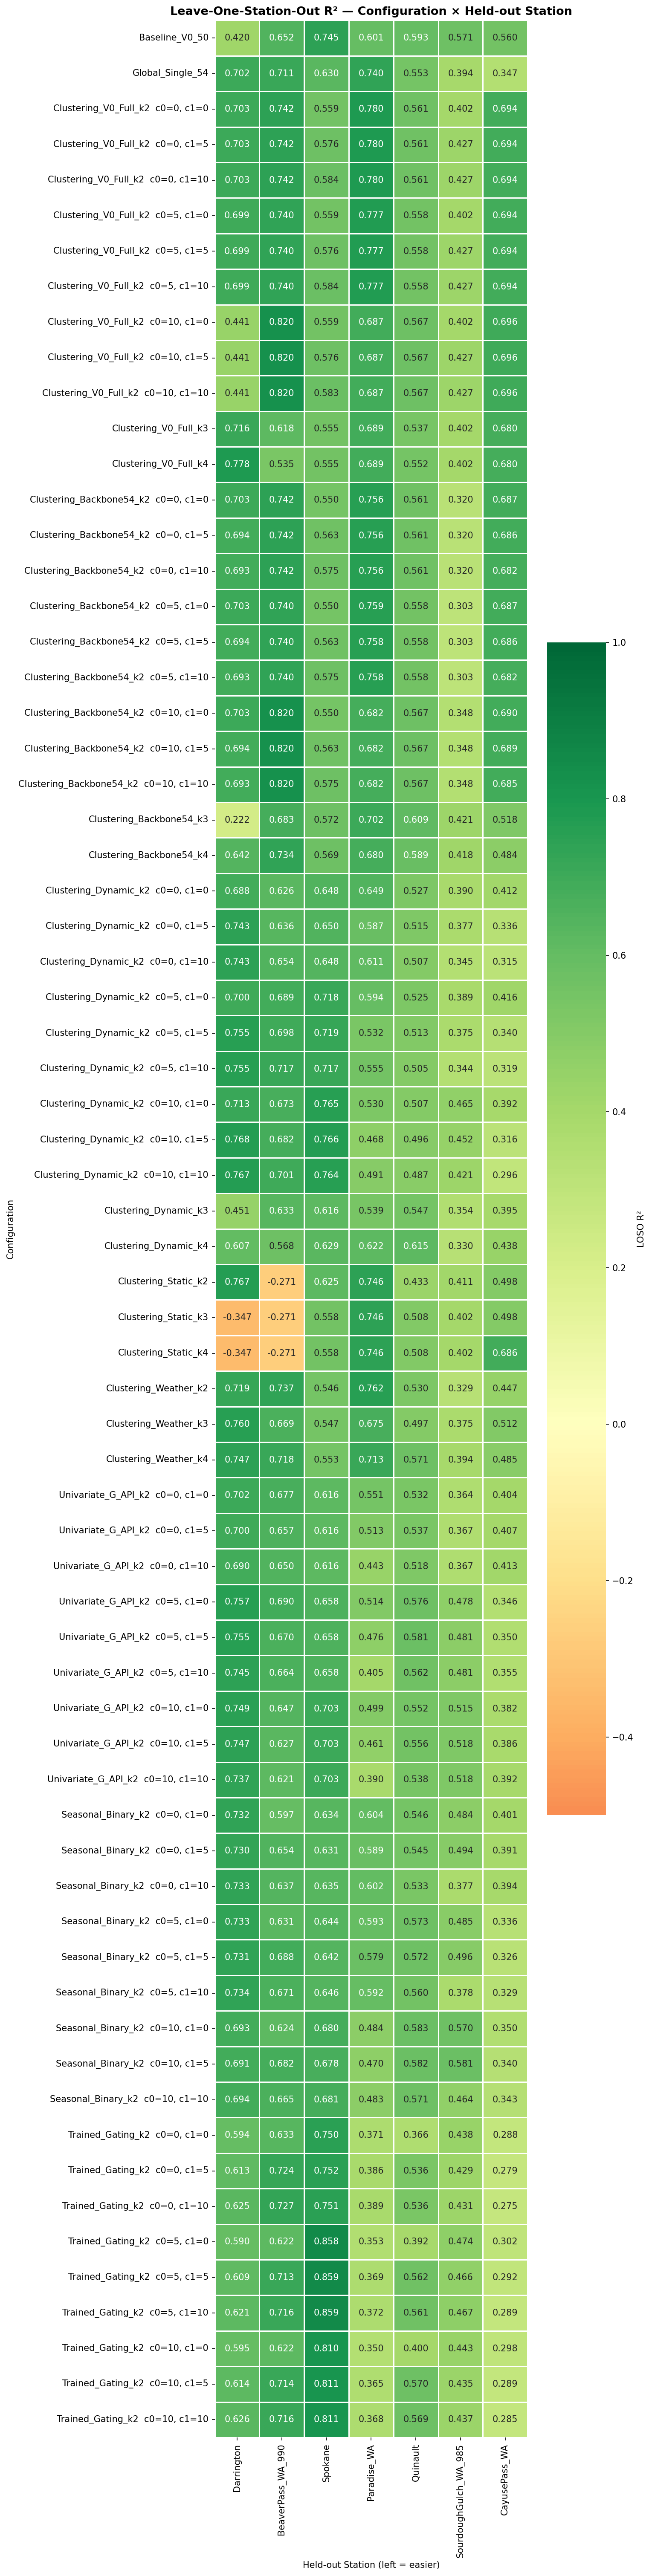

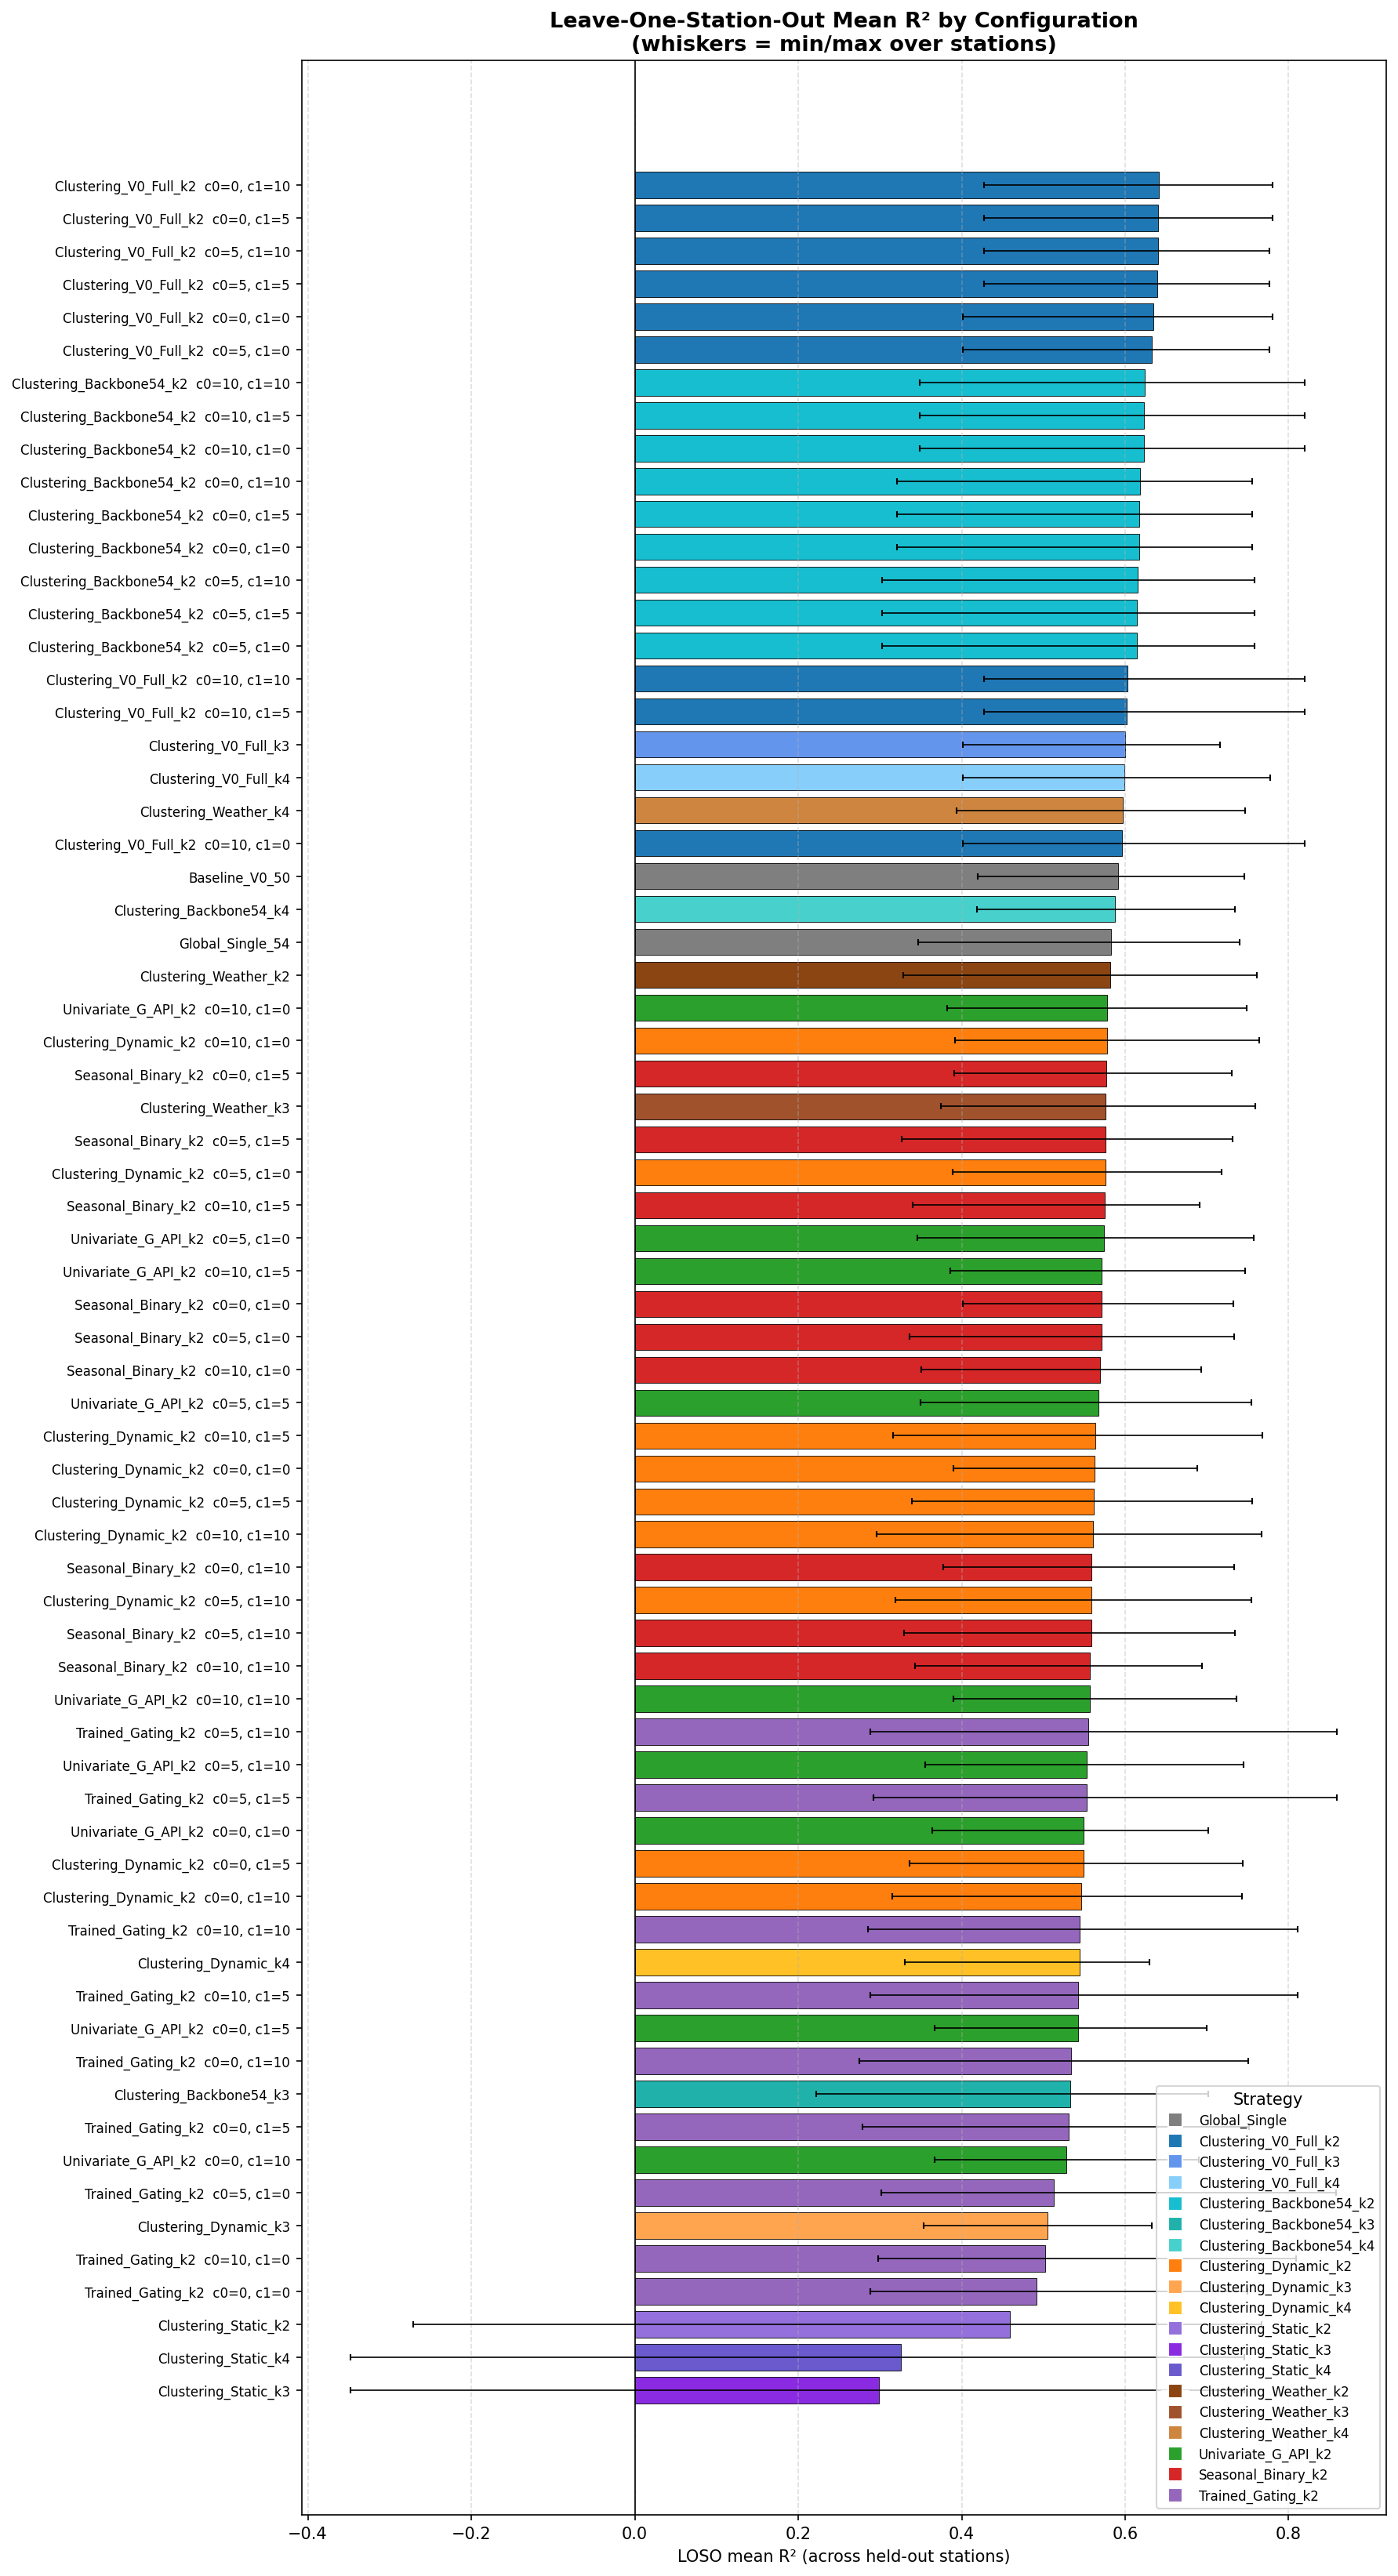

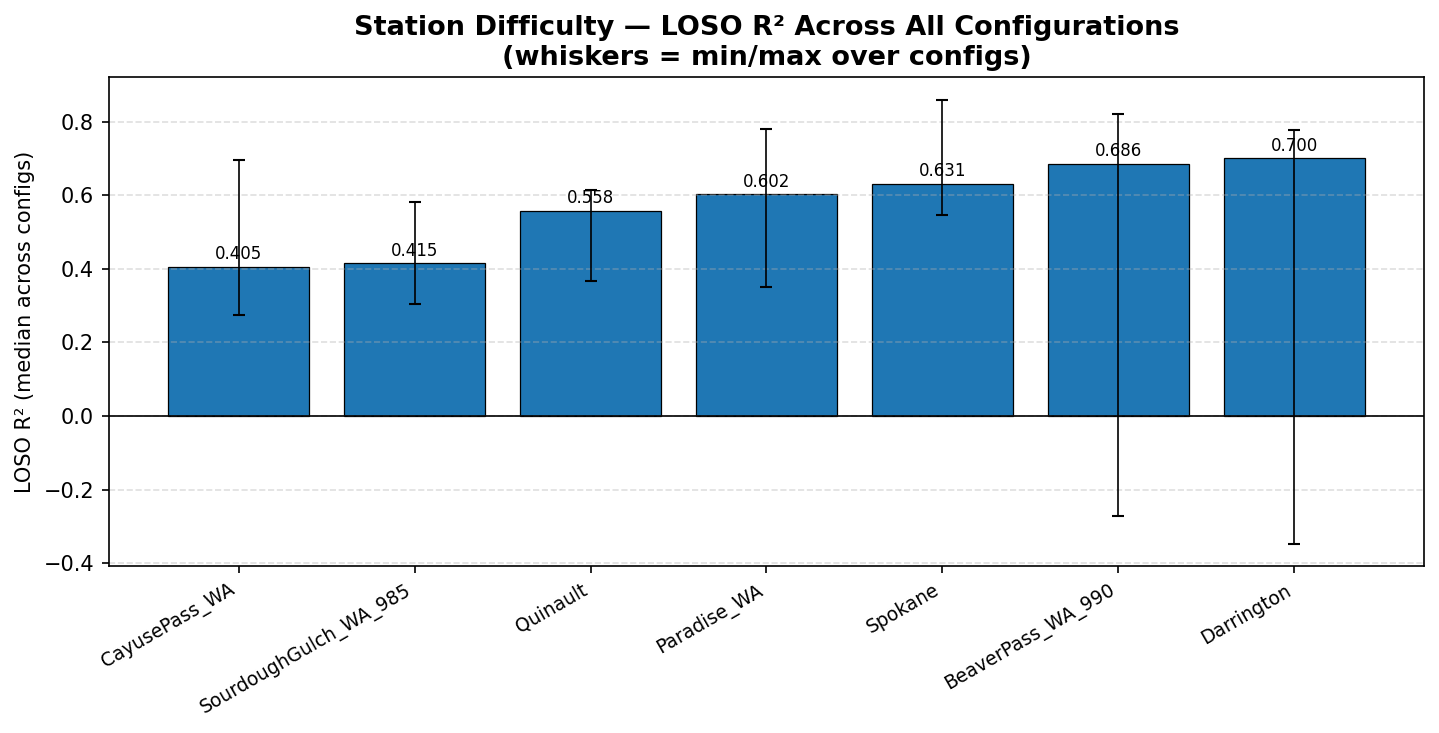

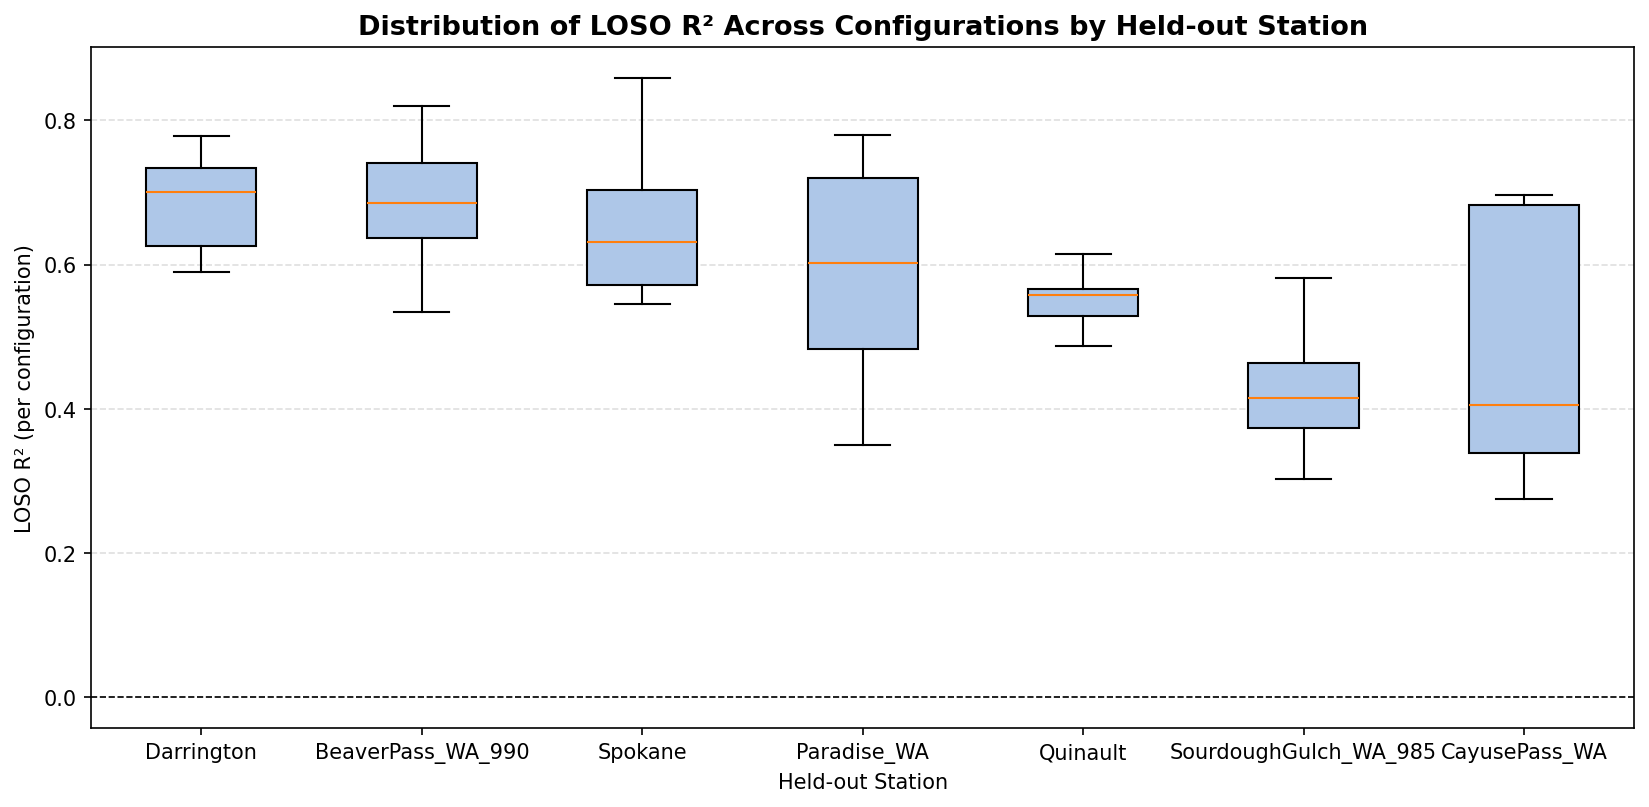

In [7]:
for fig in [
    "loso_r2_config_station_heatmap.png",
    "loso_r2_config_summary.png",
    "loso_station_difficulty.png",
    "loso_r2_station_boxplot.png",
]:
    display(Image(filename=str(EXP_DIR / fig)))


## Single-Regime → Two-Regime Development (`Clustering_Backbone54_k2`)

The two-regime model is presented as a **development of the single-regime model**, not a separate architecture: the router (KMeans k=2) and both specialists use the **same 54 shared-backbone features** as `Global_Single_54`, with only the per-cluster delta additions (pinned from eval-1.1's `Clustering_V0_Full_k2` winner) added to the second specialist. This avoids having to explain a separate V0-50 feature source. The development line below compares the single-regime global model, the new two-regime model (pinned winner c0=0, c1=10), and the eval-1.1 `Clustering_V0_Full_k2` winner (the previous best spatial generalizer), followed by the new strategy's full 9-point delta grid.


In [8]:
dev_ids = [
    "Global_Single_54",
    "Clustering_Backbone54_k2_c0_0_c1_10",
    "Clustering_V0_Full_k2_c0_0_c1_10",
]
line_map = {
    "Global_Single_54": "single-regime global (54 feats)",
    "Clustering_Backbone54_k2_c0_0_c1_10": "two-regime 54-backbone (NEW, winner)",
    "Clustering_V0_Full_k2_c0_0_c1_10": "two-regime V0-routed (eval-1.1 winner)",
}
dev = df_summary[df_summary["config_id"].isin(dev_ids)].copy()
dev["line"] = dev["config_id"].map(line_map)
dev = dev.set_index("line").loc[list(line_map.values())].reset_index()
dev_cols = ["line", "loso_mean_r2", "loso_pooled_r2", "loso_min_r2", "loso_max_r2",
            "loso_mean_rmse", "loso_mean_bias", "temporal_test_r2", "temporal_test_rmse",
            "temporal_test_bias", "temporal_test_mae", "loso_minus_test_r2"]
print("### Development line: single-regime 54 → two-regime 54")
print(dev[dev_cols].to_markdown(index=False))

grid54 = df_summary[df_summary["strategy_name"] == "Clustering_Backbone54_k2"].sort_values(
    ["cluster_0_count", "cluster_1_count"])
grid_cols = ["config_label", "loso_mean_r2", "loso_pooled_r2", "loso_mean_rmse",
             "loso_mean_bias", "temporal_test_r2", "temporal_test_rmse",
             "temporal_test_bias", "temporal_test_mae", "is_winner"]
print("\n### Clustering_Backbone54_k2 — full 9-point delta grid")
print(grid54[grid_cols].to_markdown(index=False))

### Development line: single-regime 54 → two-regime 54
| line                                   |   loso_mean_r2 |   loso_pooled_r2 |   loso_min_r2 |   loso_max_r2 |   loso_mean_rmse |   loso_mean_bias |   temporal_test_r2 |   temporal_test_rmse |   temporal_test_bias |   temporal_test_mae |   loso_minus_test_r2 |
|:---------------------------------------|---------------:|-----------------:|--------------:|--------------:|-----------------:|-----------------:|-------------------:|---------------------:|---------------------:|--------------------:|---------------------:|
| single-regime global (54 feats)        |       0.582615 |         0.607008 |      0.347175 |      0.740322 |        0.0607468 |        0.0225669 |           0.77923  |            0.0478636 |           0.0105484  |           0.0370592 |            -0.196616 |
| two-regime 54-backbone (NEW, winner)   |       0.618528 |         0.670496 |      0.320446 |      0.755575 |        0.0572762 |        0.0159406 |           0.8

## Regime-Count K-Sweep under LOSO (K = 2, 3, 4)

The gating analysis (`derived_8.4-gating-analysis-1.0`) showed K=2 is the largest regime count at which every regime is a whole station group (purity 1.000), while K=3/4 fragment stations. This section tests the spatial-generalization question directly: **does adding regimes help or hurt LOSO performance?** For each clustering router family (54-backbone / V0 / dynamic / static / weather), the K=2 row is the already-evaluated no-additions grid point (`c0=0, c1=0` for Backbone54/V0/Dynamic — identical experts: 54 backbone only), and K=3/4 are the NEW configurations with the same backbone-only experts. All rows share the same 54-feature backbone experts, so differences isolate the *routing* (regime definition).


In [9]:
ksweep_families = {
    "Clustering_Backbone54": ["Clustering_Backbone54_k2_c0_0_c1_0", "Clustering_Backbone54_k3", "Clustering_Backbone54_k4"],
    "Clustering_V0_Full":    ["Clustering_V0_Full_k2_c0_0_c1_0",    "Clustering_V0_Full_k3",    "Clustering_V0_Full_k4"],
    "Clustering_Dynamic":    ["Clustering_Dynamic_k2_c0_0_c1_0",    "Clustering_Dynamic_k3",    "Clustering_Dynamic_k4"],
    "Clustering_Static":     ["Clustering_Static_k2",               "Clustering_Static_k3",     "Clustering_Static_k4"],
    "Clustering_Weather":    ["Clustering_Weather_k2",              "Clustering_Weather_k3",    "Clustering_Weather_k4"],
}
ksweep_rows = []
for family, ids in ksweep_families.items():
    sub = df_summary[df_summary["config_id"].isin(ids)].copy()
    sub = sub.set_index("config_id").loc[ids].reset_index()
    for _, row in sub.iterrows():
        ksweep_rows.append({
            "router_family": family,
            "config_label": row["config_label"],
            "loso_mean_r2": row["loso_mean_r2"],
            "loso_pooled_r2": row["loso_pooled_r2"],
            "loso_mean_rmse": row["loso_mean_rmse"],
            "loso_mean_bias": row["loso_mean_bias"],
            "temporal_test_r2": row["temporal_test_r2"],
            "temporal_test_rmse": row["temporal_test_rmse"],
            "temporal_test_bias": row["temporal_test_bias"],
            "temporal_test_mae": row["temporal_test_mae"],
            "loso_minus_test_r2": row["loso_minus_test_r2"],
            "is_reference": row["is_reference"],
        })
ksweep = pd.DataFrame(ksweep_rows)
print("### Regime-count K-sweep under LOSO (all experts = 54-feature backbone, no additions)")
print(ksweep.to_markdown(index=False))
print("\nK=2 rows for Backbone54/V0_Full/Dynamic are the c0=0, c1=0 grid points from eval-1.1/1.3 "
      "(identical experts); Static/Weather K=2 are NEW configs computed in eval-1.4.")

### Regime-count K-sweep under LOSO (all experts = 54-feature backbone, no additions)
| router_family         | config_label                         |   loso_mean_r2 |   loso_pooled_r2 |   loso_mean_rmse |   loso_mean_bias |   temporal_test_r2 |   temporal_test_rmse |   temporal_test_bias |   temporal_test_mae |   loso_minus_test_r2 | is_reference   |
|:----------------------|:-------------------------------------|---------------:|-----------------:|-----------------:|-----------------:|-------------------:|---------------------:|---------------------:|--------------------:|---------------------:|:---------------|
| Clustering_Backbone54 | Clustering_Backbone54_k2  c0=0, c1=0 |       0.617115 |         0.668607 |        0.0573869 |       0.0156124  |           0.814205 |            0.043909  |           0.00576399 |           0.0337801 |            -0.19709  | True           |
| Clustering_Backbone54 | Clustering_Backbone54_k3             |       0.532507 |         0.57291  |        0.

## Clustering Feature Sets under LOSO (Backbone54 / Static / Weather / Dynamic / V0_Full)

The gating analysis clustered on five feature sets: the 54 shared-backbone features (the primary strategy), 58 static environmental attributes (station-pure by construction, but grouping stations differently than the backbone), 16 weather drivers (nearly station-pure with 1.5–6.5% temporal mixing), 3 dynamic features (retained legacy), and the 50 V0 features. This section compares those routers under LOSO at K=2 (all experts still the 54 backbone) and shows the per-regime breakdown of the NEW configurations — including how many test samples each regime receives and each regime's R².


In [10]:
k2_ids = {
    "Clustering_Backbone54_k2_c0_0_c1_0": "54 backbone",
    "Clustering_V0_Full_k2_c0_0_c1_0": "50 V0 features",
    "Clustering_Dynamic_k2_c0_0_c1_0": "3 dynamic features",
    "Clustering_Static_k2": "58 static attributes",
    "Clustering_Weather_k2": "16 weather drivers",
}
k2 = df_summary[df_summary["config_id"].isin(k2_ids)].copy()
k2["router_features"] = k2["config_id"].map(k2_ids)
k2 = k2.set_index("router_features").loc[list(k2_ids.values())].reset_index()
print("### K=2 routing feature sets under LOSO (all experts = 54 backbone, no additions)")
print(k2[["router_features", "config_label", "loso_mean_r2", "loso_pooled_r2",
          "loso_mean_rmse", "loso_mean_bias", "temporal_test_r2", "temporal_test_rmse",
          "temporal_test_bias", "temporal_test_mae", "loso_minus_test_r2",
          "is_reference"]].to_markdown(index=False))

new_ids = [c for c in df_summary["config_id"]
           if c in {"Clustering_Backbone54_k3", "Clustering_Backbone54_k4",
                    "Clustering_Static_k2", "Clustering_Static_k3", "Clustering_Static_k4",
                    "Clustering_Weather_k2", "Clustering_Weather_k3", "Clustering_Weather_k4",
                    "Clustering_Dynamic_k3", "Clustering_Dynamic_k4",
                    "Clustering_V0_Full_k3", "Clustering_V0_Full_k4"}]
reg = df_regime[df_regime["config_id"].isin(new_ids)].copy()
reg_rows = reg.groupby(["config_id", "cluster"]).agg(
    n_test=("n_test", "sum"),
    mean_r2=("r2", "mean"),
    min_r2=("r2", "min"),
    max_r2=("r2", "max"),
).reset_index()
reg_rows = reg_rows.sort_values(["config_id", "cluster"])
print("\n### Per-regime breakdown under LOSO — NEW gating configurations (54-backbone experts)")
print(reg_rows.to_markdown(index=False))

### K=2 routing feature sets under LOSO (all experts = 54 backbone, no additions)
| router_features      | config_label                         |   loso_mean_r2 |   loso_pooled_r2 |   loso_mean_rmse |   loso_mean_bias |   temporal_test_r2 |   temporal_test_rmse |   temporal_test_bias |   temporal_test_mae |   loso_minus_test_r2 | is_reference   |
|:---------------------|:-------------------------------------|---------------:|-----------------:|-----------------:|-----------------:|-------------------:|---------------------:|---------------------:|--------------------:|---------------------:|:---------------|
| 54 backbone          | Clustering_Backbone54_k2  c0=0, c1=0 |       0.617115 |         0.668607 |        0.0573869 |       0.0156124  |           0.814205 |            0.043909  |           0.00576399 |           0.0337801 |            -0.19709  | True           |
| 50 V0 features       | Clustering_V0_Full_k2  c0=0, c1=0    |       0.63434  |         0.682097 |        0.0562448 


### Per-regime breakdown under LOSO — NEW gating configurations (54-backbone experts)
| config_id                |   cluster |   n_test |        mean_r2 |        min_r2 |       max_r2 |
|:-------------------------|----------:|---------:|---------------:|--------------:|-------------:|
| Clustering_Backbone54_k3 |         0 |     1774 |     -0.579891  |     -1.43698  |   0.154836   |
| Clustering_Backbone54_k3 |         1 |     1060 |     -0.312     |     -2.12809  |   0.722527   |
| Clustering_Backbone54_k3 |         2 |     3786 |      0.46454   |      0.220895 |   0.609171   |
| Clustering_Backbone54_k4 |         0 |     2160 |     -1.09193   |     -3.0082   |   0.550608   |
| Clustering_Backbone54_k4 |         1 |      768 |     -0.820811  |     -1.82037  |  -0.00365472 |
| Clustering_Backbone54_k4 |         2 |     1693 |      0.129924  |     -0.550858 |   0.741547   |
| Clustering_Backbone54_k4 |         3 |     1999 |     -0.0434261 |     -2.00435  |   0.767611   |
| Clustering_

## Station Similarity & Clustering — Spatial-Generalization Hypothesis

**Hypothesis.** A station generalizes well spatially when the LOSO training set contains another station with *similar climate and geography* ("a twin"), and poorly when the station *stands out* from the rest. This section builds per-station feature vectors — WorldClim BioClim BIO1-19, geography, and soil texture from `data/splits/derived_8.4/station_static_features.csv`, plus observed climatology (mean/std of precip, LST, NDVI, SMAP, soil moisture over train+val) — then clusters the 7 stations (Ward + PCA) and tests the hypothesis by correlating per-station isolation metrics against two LOSO difficulty measures: the median R² over all 56 configurations and the per-station R² of the best spatial generalizer (the pinned `Clustering_Backbone54_k2` winner). Implementation lives in `eval13/station_sim.py`; every number below is computed by this notebook.


In [11]:
import sys
import yaml

sys.path.insert(0, str(EXP_DIR.resolve()))
from eval14 import station_sim as ss

with open(EXP_DIR / "config.yaml") as f:
    _cfg = yaml.safe_load(f)
PROJECT_ROOT = Path("../../..").resolve()

feats = ss.build_station_features(PROJECT_ROOT, _cfg)
print(f"Feature sets: {len(ss.GEO_FEATURES)} geography, {len(ss.BIOCLIM_FEATURES)} BioClim, "
      f"{len(ss.SOIL_FEATURES)} soil, {len(ss.DYNAMIC_FEATURES)} observed-climatology "
      f"({len(ss.STATIC_FEATURES) + len(ss.DYNAMIC_FEATURES)} total).")
print(f"Land cover: {dict(feats.landcover)}")

diff = ss.load_difficulty(EXP_DIR)
profile = ss.station_profile_table(feats, {"median_r2": diff["median_r2"]})
print("\n### Station profiles (MAT = annual mean temp °C×10, MAP = annual precip mm)")
print(profile.to_markdown())


Feature sets: 6 geography, 19 BioClim, 4 soil, 10 observed-climatology (39 total).
Land cover: {'Spokane': 'Tree cover', 'Darrington': 'Tree cover', 'Quinault': 'Tree cover', 'SourdoughGulch_WA_985': 'Grassland', 'BeaverPass_WA_990': 'Tree cover', 'CayusePass_WA': 'Tree cover', 'Paradise_WA': 'Tree cover'}

### Station profiles (MAT = annual mean temp °C×10, MAP = annual precip mm)
| station_id            | landcover   |   latitude |   longitude |   J_elev_m |   J_slope_deg |   J_bio_bio01 |   J_bio_bio12 |   J_sand_wfrac_b0 |   J_clay_wfrac_b0 |   mean_precip_mm |   mean_LST_modis |   mean_F_NDVI |   mean_soil_moisture_5cm |   median_r2 |
|:----------------------|:------------|-----------:|------------:|-----------:|--------------:|--------------:|--------------:|------------------:|------------------:|-----------------:|-----------------:|--------------:|-------------------------:|------------:|
| Spokane               | Tree cover  |      47.42 |     -117.53 |        705 |          

### Pairwise station distance

Euclidean distance on the z-scored 39-feature vector (29 static + 10 observed climatology). `nn_dist` (1-NN) is the distance to the closest *other* station — a small value means the station has a climate/geography "twin" in the dataset.


In [12]:
X_std = ss.standardize(feats.combined)
dist = ss.pairwise_distance(X_std)
print("### Pairwise Euclidean distance (standardized static + observed features)")
print(dist.round(2).to_markdown())


### Pairwise Euclidean distance (standardized static + observed features)
| station_id            |   Spokane |   Darrington |   Quinault |   SourdoughGulch_WA_985 |   BeaverPass_WA_990 |   CayusePass_WA |   Paradise_WA |
|:----------------------|----------:|-------------:|-----------:|------------------------:|--------------------:|----------------:|--------------:|
| Spokane               |      0    |         9.57 |      12.85 |                    4.14 |               10.56 |           11.06 |         11.56 |
| Darrington            |      9.57 |         0    |       7.58 |                    9.39 |                8.14 |            8.64 |          8.92 |
| Quinault              |     12.85 |         7.58 |       0    |                   12.64 |               11.59 |           10.17 |          9.05 |
| SourdoughGulch_WA_985 |      4.14 |         9.39 |      12.64 |                    0    |                9.86 |           10.31 |         10.94 |
| BeaverPass_WA_990     |     10.56 | 

### Hierarchical clustering and PCA

Ward linkage on the same standardized features; flat cluster assignments at k = 2 and k = 3 (k = 2 mirrors the MoE routers' two-regime split). PCA gives a 2-D view of the station embedding.


In [13]:
Z = ss.ward_linkage(X_std)
order = ss.leaf_order(Z, list(X_std.index))
print("Dendrogram leaf order:", order)
for k in (2, 3):
    print(f"\n### Ward clusters (k={k})")
    cl = ss.cluster_labels(Z, k, list(X_std.index)).to_frame("cluster")
    cl["median_r2"] = diff["median_r2"]
    print(cl.to_markdown())
scores, ev, loadings = ss.pca_projection(X_std)
print(f"\nPCA explained variance: PC1 = {ev[0]:.1%}, PC2 = {ev[1]:.1%} (total {ev.sum():.1%})")


Dendrogram leaf order: ['Spokane', 'SourdoughGulch_WA_985', 'Darrington', 'Quinault', 'BeaverPass_WA_990', 'CayusePass_WA', 'Paradise_WA']

### Ward clusters (k=2)
|                       |   cluster |   median_r2 |
|:----------------------|----------:|------------:|
| Spokane               |         1 |    0.630953 |
| Darrington            |         2 |    0.700017 |
| Quinault              |         2 |    0.557975 |
| SourdoughGulch_WA_985 |         1 |    0.414687 |
| BeaverPass_WA_990     |         2 |    0.685678 |
| CayusePass_WA         |         2 |    0.405422 |
| Paradise_WA           |         2 |    0.601746 |

### Ward clusters (k=3)
|                       |   cluster |   median_r2 |
|:----------------------|----------:|------------:|
| Spokane               |         1 |    0.630953 |
| Darrington            |         2 |    0.700017 |
| Quinault              |         2 |    0.557975 |
| SourdoughGulch_WA_985 |         1 |    0.414687 |
| BeaverPass_WA_990     |      

In [14]:
iso = ss.isolation_scores(X_std)
tbl = iso.join(diff[["median_r2", "mean_r2", "winner_r2"]])
tbl = tbl.sort_values("median_r2", ascending=False)
print(f"Winner config used for `winner_r2`: {diff['winner_config'].iloc[0]}")
print("\n### Isolation metrics vs LOSO difficulty")
print(tbl.round(3).to_markdown())
print("\n### Spearman rank correlation (isolation × difficulty)")
print(ss.spearman_table(iso, diff).to_markdown(index=False))


Winner config used for `winner_r2`: Clustering_Backbone54_k2_c0_0_c1_10

### Isolation metrics vs LOSO difficulty
| station_id            |   nn_dist |   mean_dist |   centroid_dist |   median_r2 |   mean_r2 |   winner_r2 |
|:----------------------|----------:|------------:|----------------:|------------:|----------:|------------:|
| Darrington            |     7.58  |       8.705 |           5.134 |       0.7   |     0.644 |       0.693 |
| BeaverPass_WA_990     |     6.546 |       8.996 |           5.759 |       0.686 |     0.651 |       0.742 |
| Spokane               |     4.138 |       9.956 |           7.254 |       0.631 |     0.646 |       0.575 |
| Paradise_WA           |     2.23  |       8.331 |           5.343 |       0.602 |     0.596 |       0.756 |
| Quinault              |     7.58  |      10.649 |           7.831 |       0.558 |     0.542 |       0.561 |
| SourdoughGulch_WA_985 |     4.138 |       9.546 |           6.71  |       0.415 |     0.416 |       0.32  |
| Cayu

| isolation_metric   | difficulty_metric   |   spearman_rho |   p_value |   n |
|:-------------------|:--------------------|---------------:|----------:|----:|
| nn_dist            | median_r2           |          0.551 |     0.2   |   7 |
| nn_dist            | mean_r2             |          0.312 |     0.496 |   7 |
| nn_dist            | winner_r2           |         -0.22  |     0.635 |   7 |
| mean_dist          | median_r2           |          0.107 |     0.819 |   7 |
| mean_dist          | mean_r2             |          0.107 |     0.819 |   7 |
| mean_dist          | winner_r2           |         -0.643 |     0.119 |   7 |
| centroid_dist      | median_r2           |          0     |     1     |   7 |
| centroid_dist      | mean_r2             |          0.071 |     0.879 |   7 |
| centroid_dist      | winner_r2           |         -0.571 |     0.18  |   7 |


In [15]:
# Sensitivity: static features only (geography + BioClim + soil; no target-derived
# observed climatology) — confirms the correlation pattern is not an artifact of
# including mean/std soil moisture in the feature vector.
X_static = ss.standardize(feats.static)
iso_static = ss.isolation_scores(X_static)
print("### Sensitivity — static features only (geography + BioClim + soil)")
print(ss.spearman_table(iso_static, diff).to_markdown(index=False))


### Sensitivity — static features only (geography + BioClim + soil)
| isolation_metric   | difficulty_metric   |   spearman_rho |   p_value |   n |
|:-------------------|:--------------------|---------------:|----------:|----:|
| nn_dist            | median_r2           |          0.624 |     0.134 |   7 |
| nn_dist            | mean_r2             |          0.532 |     0.219 |   7 |
| nn_dist            | winner_r2           |         -0.037 |     0.938 |   7 |
| mean_dist          | median_r2           |          0.107 |     0.819 |   7 |
| mean_dist          | mean_r2             |          0.107 |     0.819 |   7 |
| mean_dist          | winner_r2           |         -0.643 |     0.119 |   7 |
| centroid_dist      | median_r2           |         -0.214 |     0.645 |   7 |
| centroid_dist      | mean_r2             |         -0.036 |     0.939 |   7 |
| centroid_dist      | winner_r2           |         -0.607 |     0.148 |   7 |


### Figures

Five figures summarize the station similarity structure and the hypothesis test: (1) pairwise similarity heatmap in dendrogram order, (2) Ward dendrogram with leaf colors by difficulty tier, (3) PCA embedding colored by median LOSO R² with the top feature loadings, (4) isolation-vs-difficulty scatter (1-NN / mean distance × median / winner-config R², Spearman ρ annotated), and (5) the standardized feature matrix showing which features make the hard stations extreme.


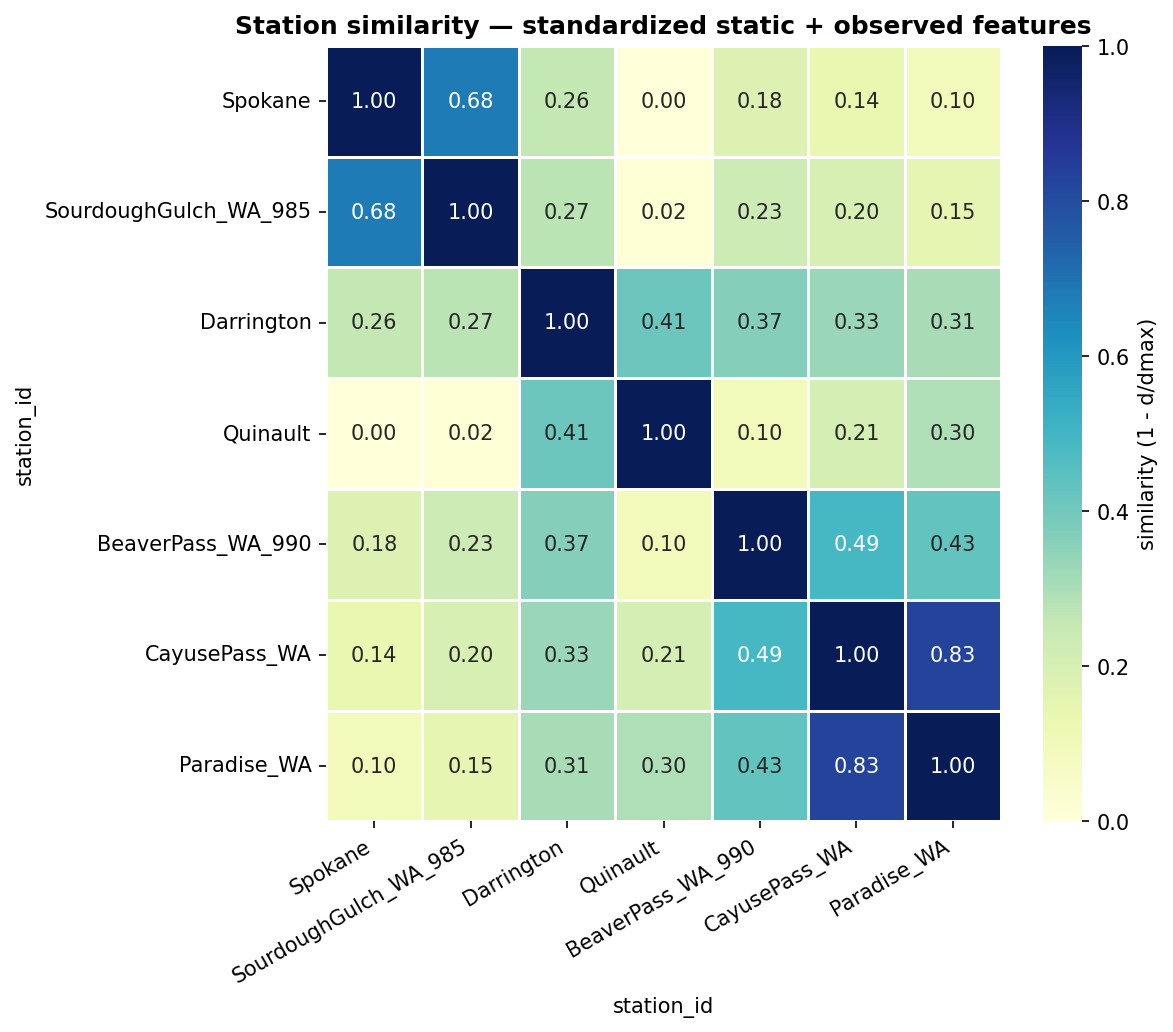

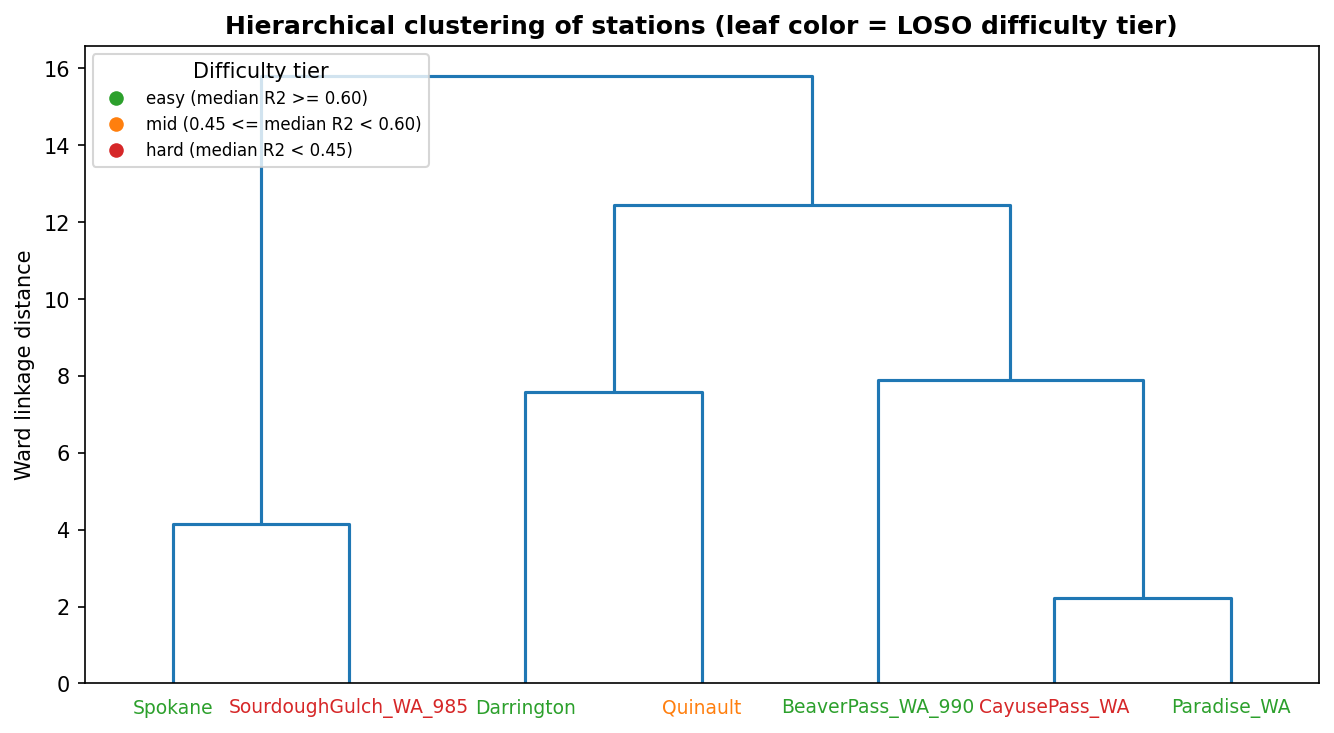

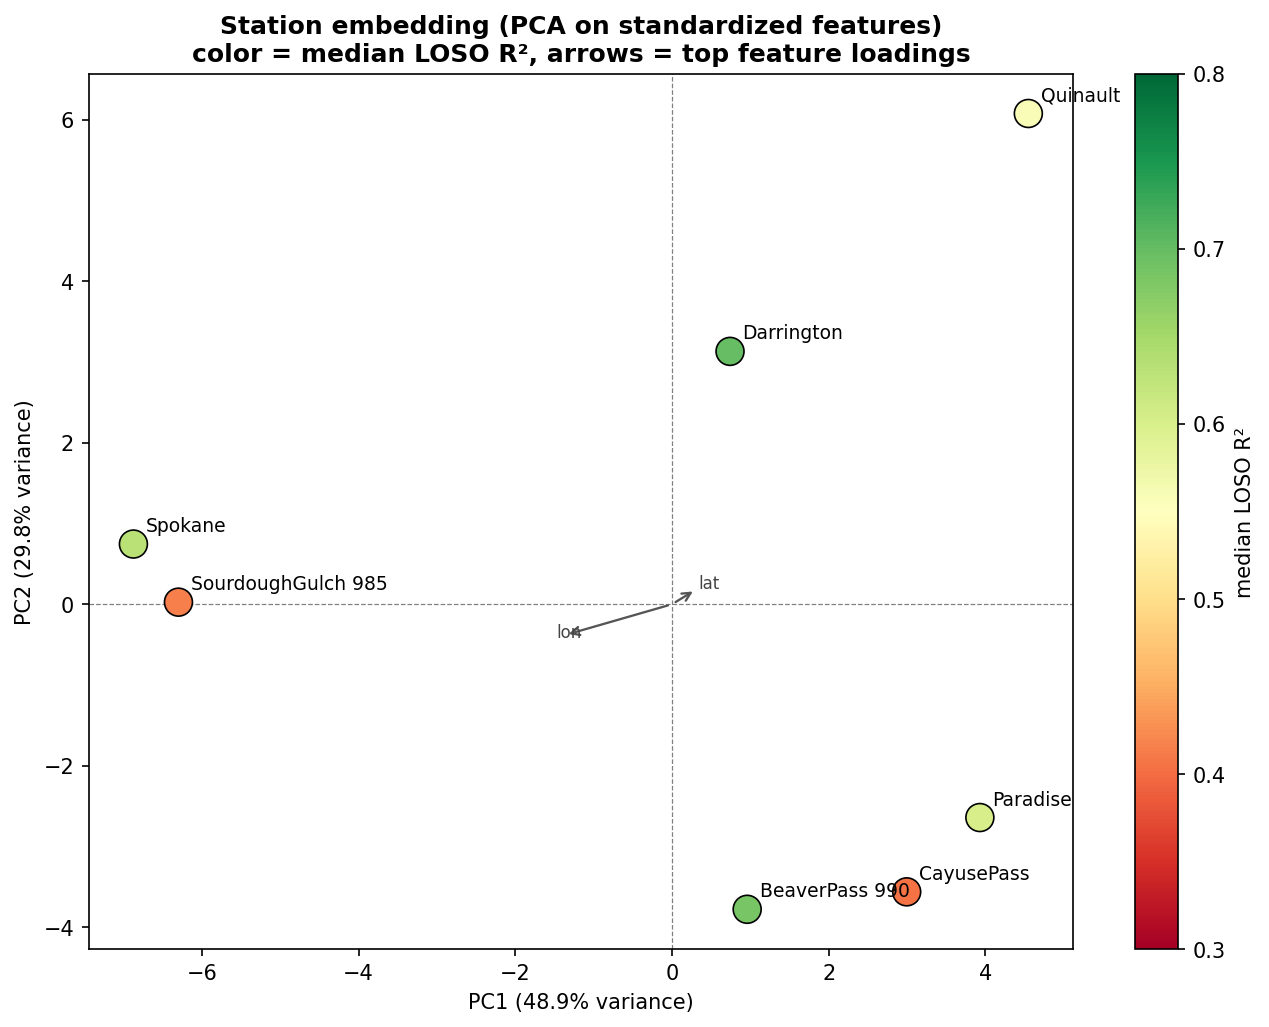

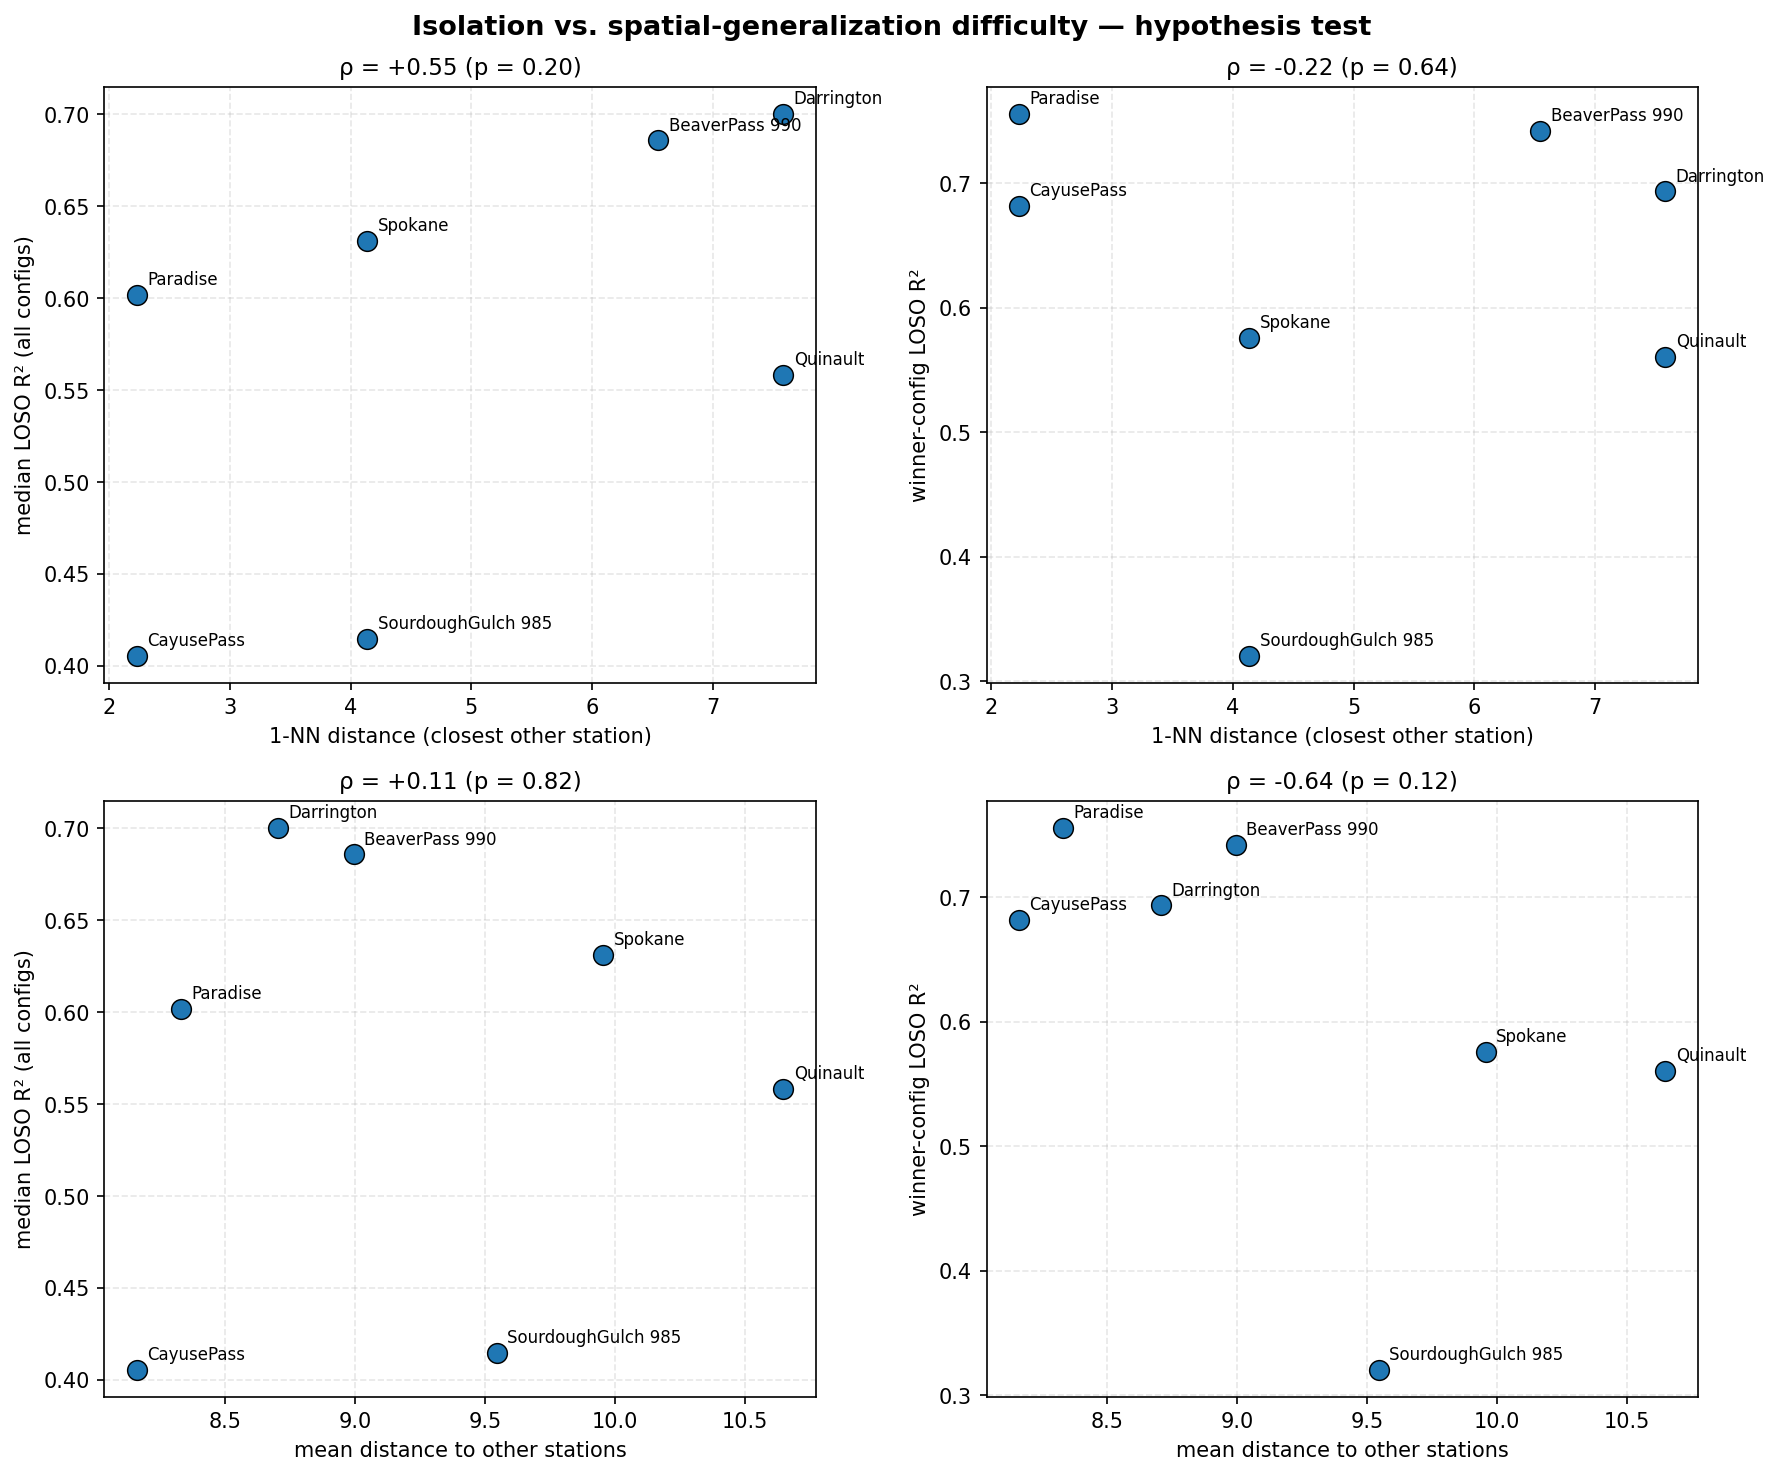

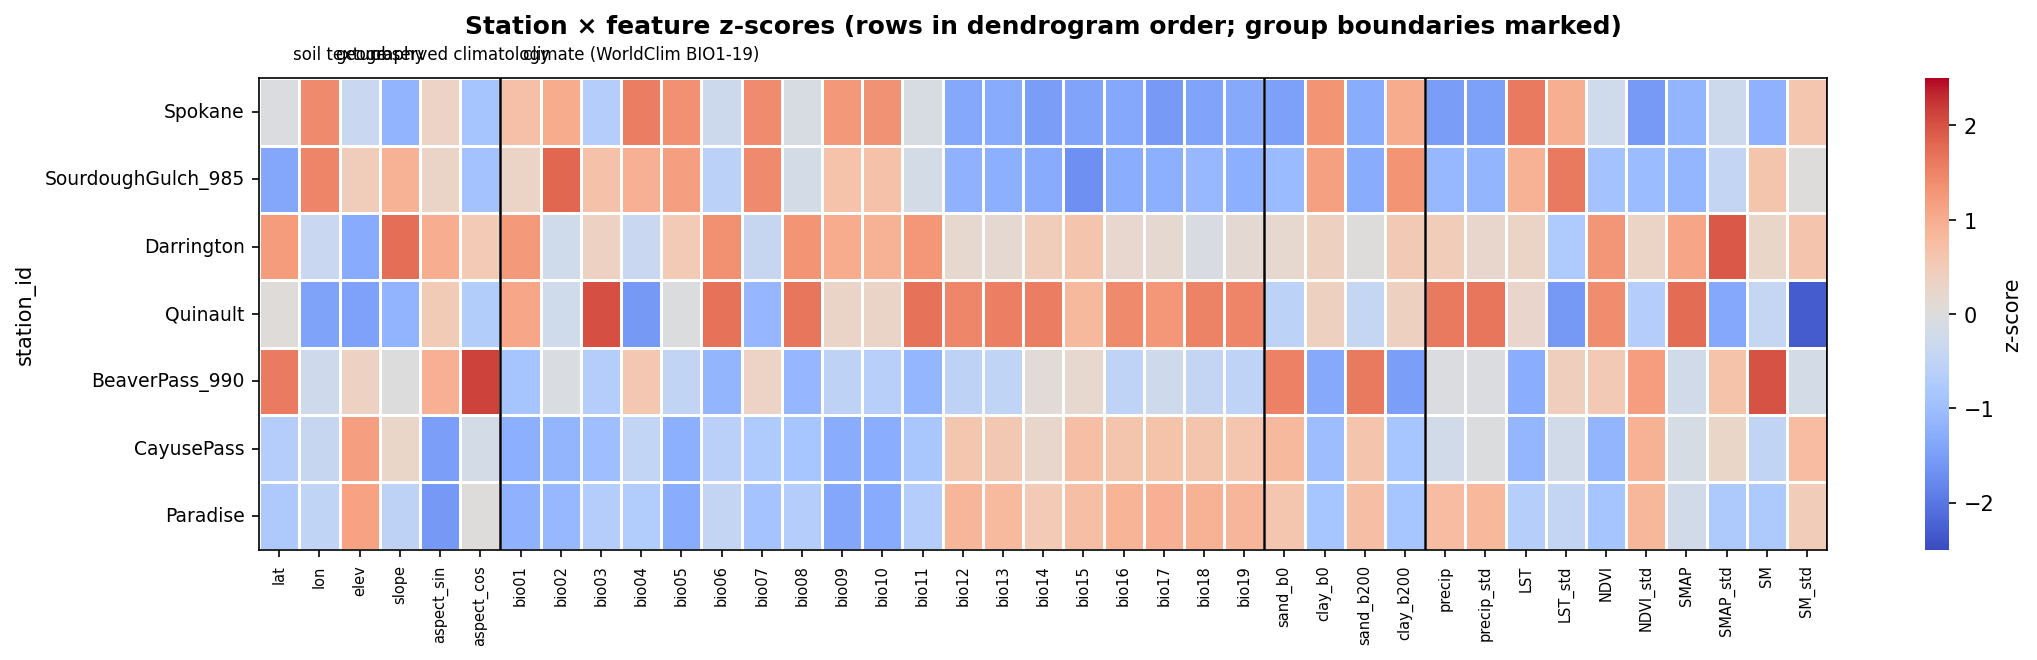

Saved 5 station-similarity figures to the experiment directory.


In [16]:
sim = ss.similarity_matrix(dist)
for fig_path in [
    ss.plot_similarity_heatmap(sim, order, EXP_DIR),
    ss.plot_dendrogram(Z, list(X_std.index), diff, EXP_DIR),
    ss.plot_pca_scatter(scores, ev, loadings, diff, EXP_DIR),
    ss.plot_isolation_vs_difficulty(iso, diff, EXP_DIR),
    ss.plot_feature_heatmap(X_std, order, EXP_DIR),
]:
    display(Image(filename=str(fig_path)))
print("Saved 5 station-similarity figures to the experiment directory.")


### Interpretation

**Similarity structure.** Ward clustering finds three natural pairs — {CayusePass, Paradise} (high-elevation Cascade sites, the tightest pair at distance 2.23), {Spokane, SourdoughGulch} (dry east-side, 4.14), and {Darrington, Quinault} (wet west-side, 7.58) — with BeaverPass joining the high-elevation group (k = 3). SourdoughGulch is the **only grassland** station (all others tree cover), i.e. the most unique by land cover.

**Hypothesis test.** The simple "twin → easy" story is **not supported** by the aggregate difficulty: 1-NN distance correlates *positively* with median LOSO R² (ρ = +0.55), i.e. the closest twins (CayusePass ↔ Paradise) are among the *hardest* stations on average. Under the best spatial generalizer (the `Clustering_Backbone54_k2` winner) the pattern flips toward the hypothesis — mean-distance isolation correlates *negatively* with winner-config R² (ρ = −0.64), and the unique grassland station SourdoughGulch is the hardest under the winner config (0.32) — but none of these correlations is significant at n = 7. Note the winner config does *well* at CayusePass (0.68) even though it is the hardest station on median across all 68 configs (0.41): the two-regime model's regional specialist transfers there, but the average config does not.

**Joint reading.** Having a static-feature twin does not rescue generalization when the twin pair is jointly *extreme* (CayusePass/Paradise: highest elevation, coldest, snow-dominated); per-station difficulty is better explained by how far a station sits from the training-regime core and by its dynamic regime (SourdoughGulch's unique land cover / low vegetation) than by pairwise similarity alone. These results are descriptive for a 7-station sample and should be treated as hypotheses, not conclusions.


## Full-Training Baseline — Intrinsic vs. Generalization Difficulty

LOSO measures how well a model *generalizes* to a station it never saw during training. But a station can be hard for two different reasons: it is **intrinsically hard** (hard to fit even when its own rows are in the training set) or **generalization-limited** (easy to fit when trained on, but degrades when held out). To separate the two, every configuration was also trained **without LOSO** — router and experts fit on the full trainval (all 7 stations), exactly the `derived_8.4-eval-1.1` protocol — and evaluated per station on the test set (`run_full_baseline.py`, same 68 configurations as LOSO). Pooled R² per configuration replicates eval-1.1 to within machine precision for the 47 pinned configurations, validating the baseline; the 9 `Clustering_Backbone54_k2` grid configurations and the 12 new gating configurations have no eval-1.1 row and their pooled R² serves as their temporal reference (the 56 existing rows merged as references from eval-1.3).


In [17]:
df_full_pcs = pd.read_csv(EXP_DIR / "full_per_config_station.csv")
df_full_summary = pd.read_csv(EXP_DIR / "full_config_summary.csv")
df_full_station = pd.read_csv(EXP_DIR / "full_station_summary.csv")

valid = df_full_summary.dropna(subset=["eval11_test_r2"])
print(f"Validation vs eval-1.1: {len(valid)} configs compared, "
      f"max |full_pooled_r2 − eval11_test_r2| = {valid['r2_diff'].max():.6f}")

full_cols = ["station", "n_configs", "total_test_n", "median_r2", "mean_r2", "std_r2",
             "min_r2", "max_r2", "mean_rmse", "mean_bias", "n_negative_r2"]
print("\n### Station difficulty under FULL training (intrinsic; median over 68 configs)")
print(df_full_station[full_cols].to_markdown(index=False))


Validation vs eval-1.1: 47 configs compared, max |full_pooled_r2 − eval11_test_r2| = 0.000000

### Station difficulty under FULL training (intrinsic; median over 68 configs)
| station               |   n_configs |   total_test_n |   median_r2 |   mean_r2 |    std_r2 |   min_r2 |   max_r2 |   mean_rmse |   mean_bias |   n_negative_r2 |
|:----------------------|------------:|---------------:|------------:|----------:|----------:|---------:|---------:|------------:|------------:|----------------:|
| Spokane               |          68 |          60996 |    0.943112 |  0.941809 | 0.0109624 | 0.915413 | 0.957031 |   0.0275905 |  0.00208759 |               0 |
| Darrington            |          68 |          67932 |    0.816379 |  0.81617  | 0.0135295 | 0.784731 | 0.841255 |   0.0400322 |  0.0227865  |               0 |
| CayusePass_WA         |          68 |          73508 |    0.76792  |  0.767352 | 0.0313888 | 0.704006 | 0.807327 |   0.057478  |  0.00567766 |               0 |
| Paradise_

### Full-training vs LOSO difficulty

Merging the per-station medians: `median_r2_full` (trained on all stations) vs `median_r2_loso` (station held out). `gap = full − loso` is the LOSO cost — a large positive gap means the station is **generalization-limited** (fine when trained on, degrades when held out); a gap near zero means it is **intrinsically hard** (hard both ways); a negative gap means it performs *better* under LOSO than full training (anomaly worth flagging).


In [18]:
cmp = df_full_station[["station", "median_r2", "mean_r2"]].merge(
    df_station[["station", "median_r2", "mean_r2"]],
    on="station", suffixes=("_full", "_loso"),
)
cmp["gap_median"] = cmp["median_r2_full"] - cmp["median_r2_loso"]
cmp["gap_mean"] = cmp["mean_r2_full"] - cmp["mean_r2_loso"]
cmp = cmp.sort_values("median_r2_loso", ascending=False)
cols = ["station", "median_r2_full", "median_r2_loso", "gap_median",
        "mean_r2_full", "mean_r2_loso", "gap_mean"]
print("### Per-station difficulty: full training vs LOSO (sorted by LOSO difficulty)")
print(cmp[cols].round(3).to_markdown(index=False))


### Per-station difficulty: full training vs LOSO (sorted by LOSO difficulty)
| station               |   median_r2_full |   median_r2_loso |   gap_median |   mean_r2_full |   mean_r2_loso |   gap_mean |
|:----------------------|-----------------:|-----------------:|-------------:|---------------:|---------------:|-----------:|
| Darrington            |            0.816 |            0.7   |        0.116 |          0.816 |          0.644 |      0.172 |
| BeaverPass_WA_990     |            0.531 |            0.686 |       -0.154 |          0.515 |          0.651 |     -0.136 |
| Spokane               |            0.943 |            0.631 |        0.312 |          0.942 |          0.646 |      0.296 |
| Paradise_WA           |            0.762 |            0.602 |        0.16  |          0.76  |          0.596 |      0.163 |
| Quinault              |            0.685 |            0.558 |        0.128 |          0.681 |          0.542 |      0.139 |
| SourdoughGulch_WA_985 |            0.4

In [19]:
from scipy.stats import spearmanr
rho, p = spearmanr(cmp["median_r2_full"], cmp["median_r2_loso"])
print(f"Spearman(full median R², LOSO median R²) = {rho:+.3f} (p = {p:.3f}, n = {len(cmp)})")
print("High ρ ⇒ station difficulty is intrinsic; low ρ ⇒ LOSO difficulty is generalization-specific.")


Spearman(full median R², LOSO median R²) = +0.321 (p = 0.482, n = 7)
High ρ ⇒ station difficulty is intrinsic; low ρ ⇒ LOSO difficulty is generalization-specific.


### Figures

Three figures compare the two difficulty measures: (1) scatter of per-station median R² (full vs LOSO) with the identity line, (2) paired bars per station sorted by LOSO difficulty, and (3) per-station boxplot of the per-configuration LOSO cost (full-training R² − LOSO R²).


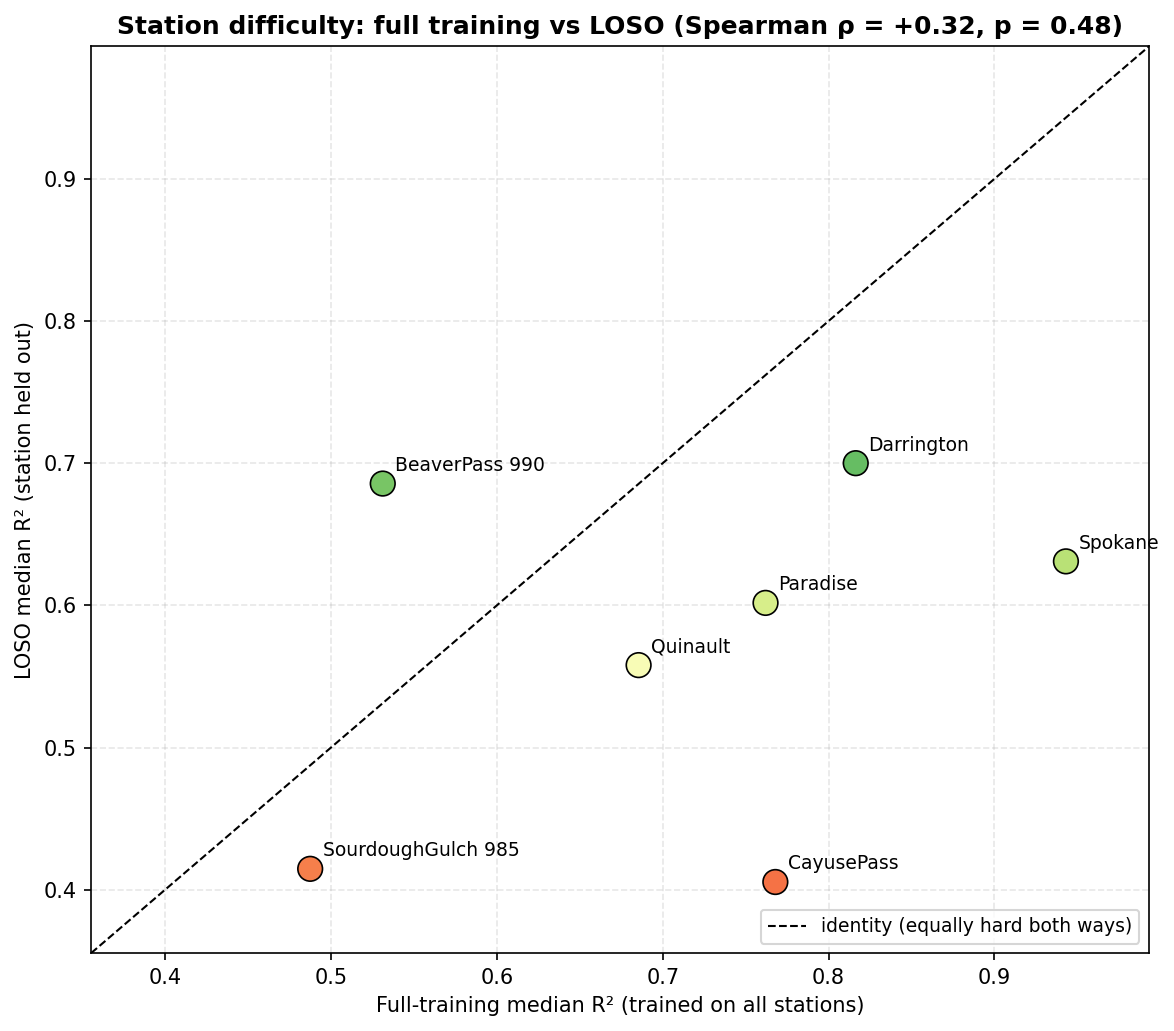

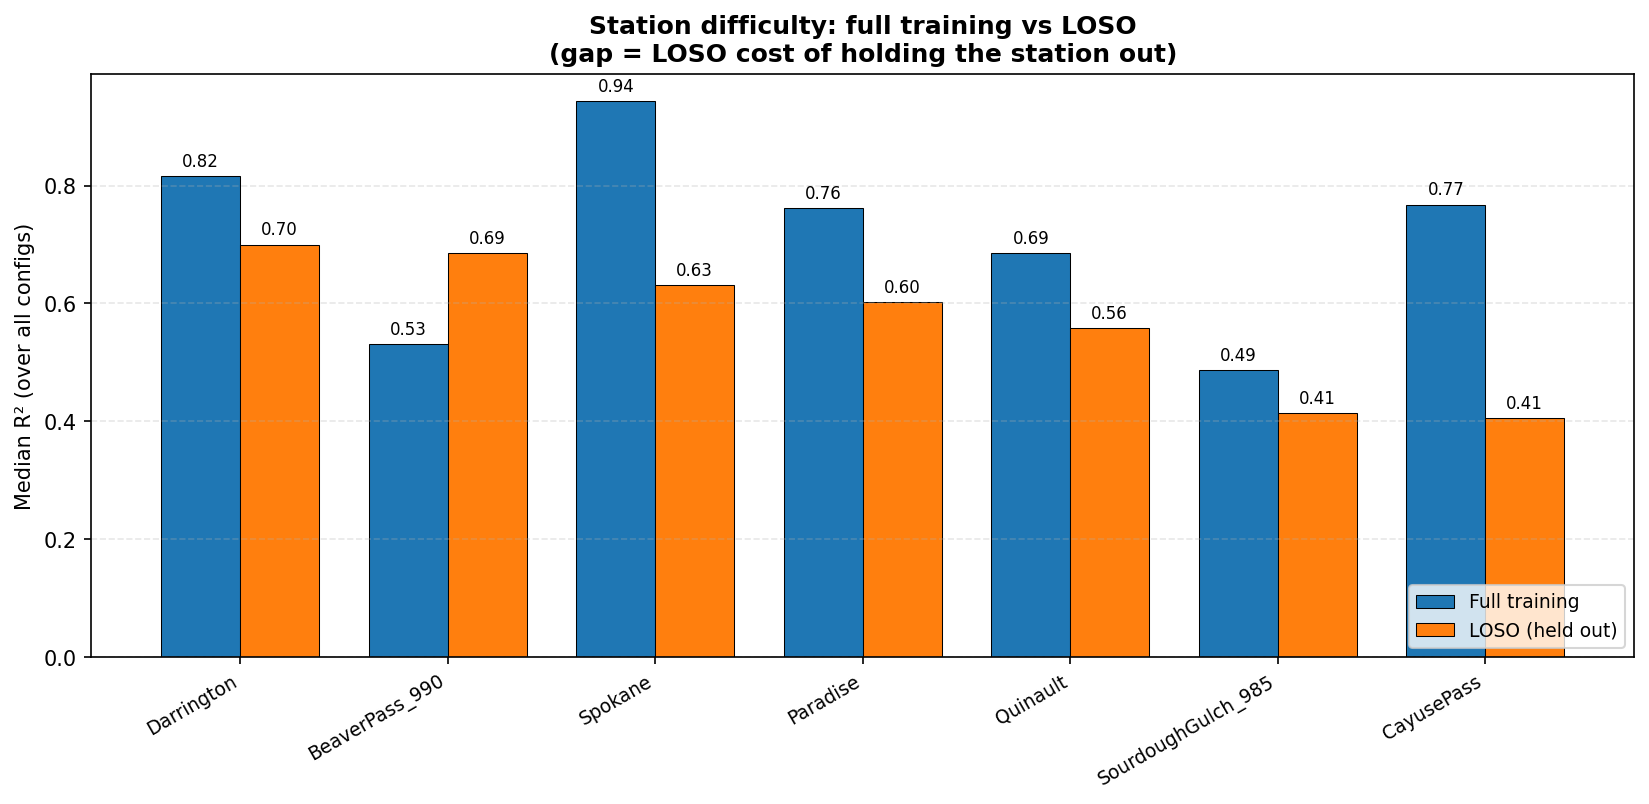

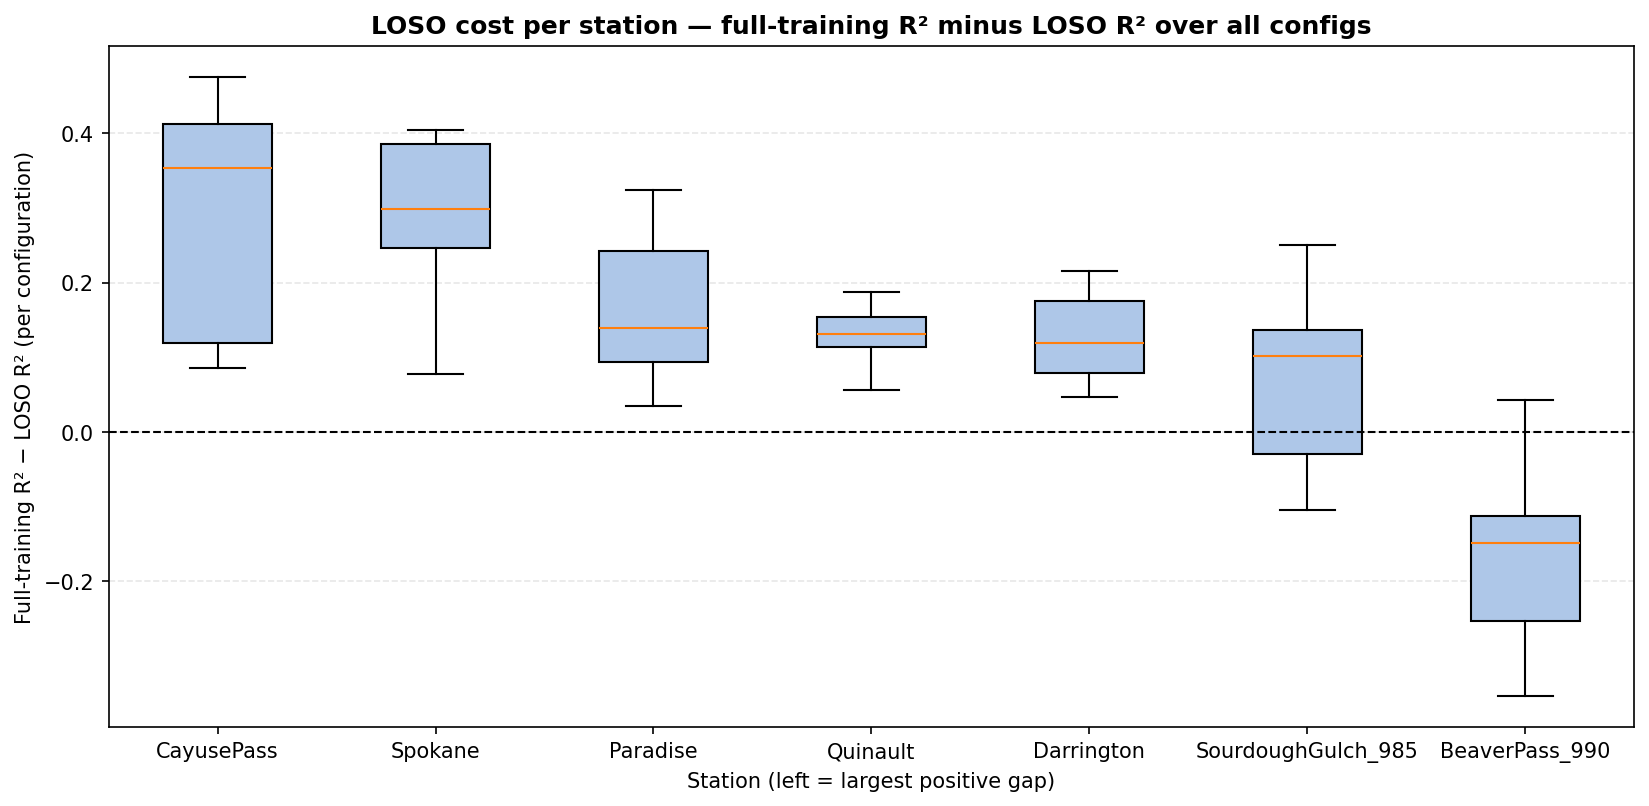

Saved 3 full-baseline comparison figures.


In [20]:
from eval14.plots import plot_full_vs_loso_scatter, plot_full_vs_loso_bars, plot_loso_gap_boxplot

cmp_plot = cmp.rename(columns={"median_r2_full": "full_median_r2", "median_r2_loso": "loso_median_r2"})
for fig_path in [
    plot_full_vs_loso_scatter(cmp_plot, EXP_DIR),
    plot_full_vs_loso_bars(cmp_plot, EXP_DIR),
    plot_loso_gap_boxplot(df_full_pcs, df_pcs, EXP_DIR),
]:
    display(Image(filename=str(fig_path)))
print("Saved 3 full-baseline comparison figures.")


### Interpretation

**Replication.** All 47 pinned configurations reproduce eval-1.1's pooled test R² exactly (max |diff| = 0.000000), so the full-training baseline is a faithful replica of 1.1 — LOSO is a true addition, not a replacement. The 9 `Clustering_Backbone54_k2` grid configurations and the 12 new gating configurations get their temporal test R² from this baseline (the 56 existing rows merged as references from eval-1.3).

**Are LOSO-hard stations also hard under full training? Only weakly.** Spearman(full median R², LOSO median R²) = +0.321 (p = 0.482, n = 7): the station-difficulty rank order changes substantially between the two protocols, so LOSO difficulty is mostly *generalization-specific* rather than intrinsic.

**The two hardest LOSO stations split cleanly:**
- **CayusePass** is **generalization-limited**: easy when trained on (full median 0.768) yet the hardest under LOSO (0.405) — gap +0.36. Its snow-dominated high-elevation regime is fit well when its own rows are present, but the other stations cannot supply that regime when it is held out.
- **SourdoughGulch** is **intrinsically hard**: 0.487 full vs 0.415 LOSO — gap only +0.07. Even with its own rows in training it remains among the hardest stations, consistent with its uniqueness (the only grassland station).

**BeaverPass anomaly.** BeaverPass is *harder* under full training (median 0.531) than under LOSO (0.686), gap −0.15 — the only station that does *better* when held out. It has the fewest test rows (626) and its regime overlaps few training rows, so including it in full training appears to hurt rather than help.

**Bottom line.** Station difficulty is not one-dimensional: LOSO difficulty measures *transfer*, full-training difficulty measures *fitability*. SourdoughGulch is hard on both axes (intrinsically hard *and* hard to generalize to); CayusePass's difficulty is almost entirely a transfer phenomenon.
